In [1]:
# setup environment
import pathlib
import numpy as np
import matplotlib.pyplot as plt

# create higher resolution plots
%config InlineBackend.figure_format = 'retina'

# set directory
filesDir = pathlib.Path('./float32')

In [2]:
# load data
samples = {}
samples['theta']         = np.load(filesDir/'fhn_T200_samplePrior_theta.npy')
samples['spikeRate']     = np.load(filesDir/'fhn_T200_samplePrior_spikeRate.npy')
samples['spikeDuration'] = np.load(filesDir/'fhn_T200_samplePrior_spikeDuration.npy')
n_samples = samples['theta'].shape[0]

print('theta        ', samples['theta'].shape        , samples['theta'].dtype)
print('spikeRate    ', samples['spikeRate'].shape    , samples['spikeRate'].dtype)
print('spikeDuration', samples['spikeDuration'].shape, samples['spikeDuration'].dtype)

theta         (10000, 2) float32
spikeRate     (10000,) float32
spikeDuration (10000,) float32


In [3]:
def _preprocess_log_transform(arrays, shift=0.0):
    for a in arrays:
        np.log(shift + a, out=a)

def _preprocess_log_transform_inverse(arrays, shift=0.0):
    for a in arrays:
        np.exp(a, out=a)
        np.add(a, -shift, out=a)

def _preprocess_apply_scale(arrays, scale):
    for a in arrays:
        np.add(a, -scale['shift'], out=a)
        np.multiply(a, 1.0/scale['mult'], out=a)

# use only a subset of samples for scaling
Ntrain = 4096

In [4]:
# calculate scaling
scale = dict()
for key in ['spikeRate', 'spikeDuration']:
    data_ = samples[key][:Ntrain, ...]
    features_min  = np.nanmin(data_)
    features_max  = np.nanmax(data_)
    features_mean = np.nanmean(data_)
    features_std  = np.nanstd(data_)
    if np.nanmedian(data_) < (features_max - 2.0*features_std): # if max seems too large
        data_ = data_[ data_ < (features_max - features_std) ]
        features_max = np.amax(data_)
    scale[key] = {'shift': features_min, 'mult': (features_max - features_min)}
print(scale)

# override scale
scale = {
    'spikeRate':     {'shift': 65.06506, 'mult': 40.04004},
    'spikeDuration': {'shift': 0.0, 'mult': 8.323077}
}
print('\nOverride scale...')
print(scale)

# apply scaling
samples_scaled = dict()
for key in ['spikeRate', 'spikeDuration']:
    samples_scaled[key] = samples[key].copy()
    _preprocess_apply_scale((samples_scaled[key],), scale[key])

{'spikeRate': {'shift': 65.06506, 'mult': 50.05005}, 'spikeDuration': {'shift': 0.0, 'mult': 8.323077}}

Override scale...
{'spikeRate': {'shift': 65.06506, 'mult': 40.04004}, 'spikeDuration': {'shift': 0.0, 'mult': 8.323077}}


In [5]:
# apply transformation
samples_transformed = dict()
for key in ['spikeRate', 'spikeDuration']:
    samples_transformed[key] = samples[key].copy()
    if 'spikeDuration' == key:
        _preprocess_log_transform((samples_transformed[key],), shift=1.0)
    
# calculate scaling
scale = dict()
for key in ['spikeRate', 'spikeDuration']:
    data_ = samples_transformed[key][:Ntrain, ...]
    features_min  = np.nanmin(data_)
    features_max  = np.nanmax(data_)
    features_mean = np.nanmean(data_)
    features_std  = np.nanstd(data_)
    if 'spikeRate' == key:
        scale[key] = {'shift': features_min, 'mult': (features_max - features_min)}
    elif 'spikeDuration' == key:
        scale[key] = {'shift': features_mean, 'mult': features_std}
    else:
        raise NotImplemented()
print(scale)

# apply scaling
for key in ['spikeRate', 'spikeDuration']:
    _preprocess_apply_scale((samples_transformed[key],), scale[key])

{'spikeRate': {'shift': 65.06506, 'mult': 50.05005}, 'spikeDuration': {'shift': 1.49648, 'mult': 0.99194986}}


In [6]:
# replace nan values
for key in ['spikeRate', 'spikeDuration']:
    samples_scaled[key]      = np.where(np.isnan(samples_scaled[key])     , -1.0, samples_scaled[key])
    samples_transformed[key] = np.where(np.isnan(samples_transformed[key]), -1.0, samples_transformed[key])

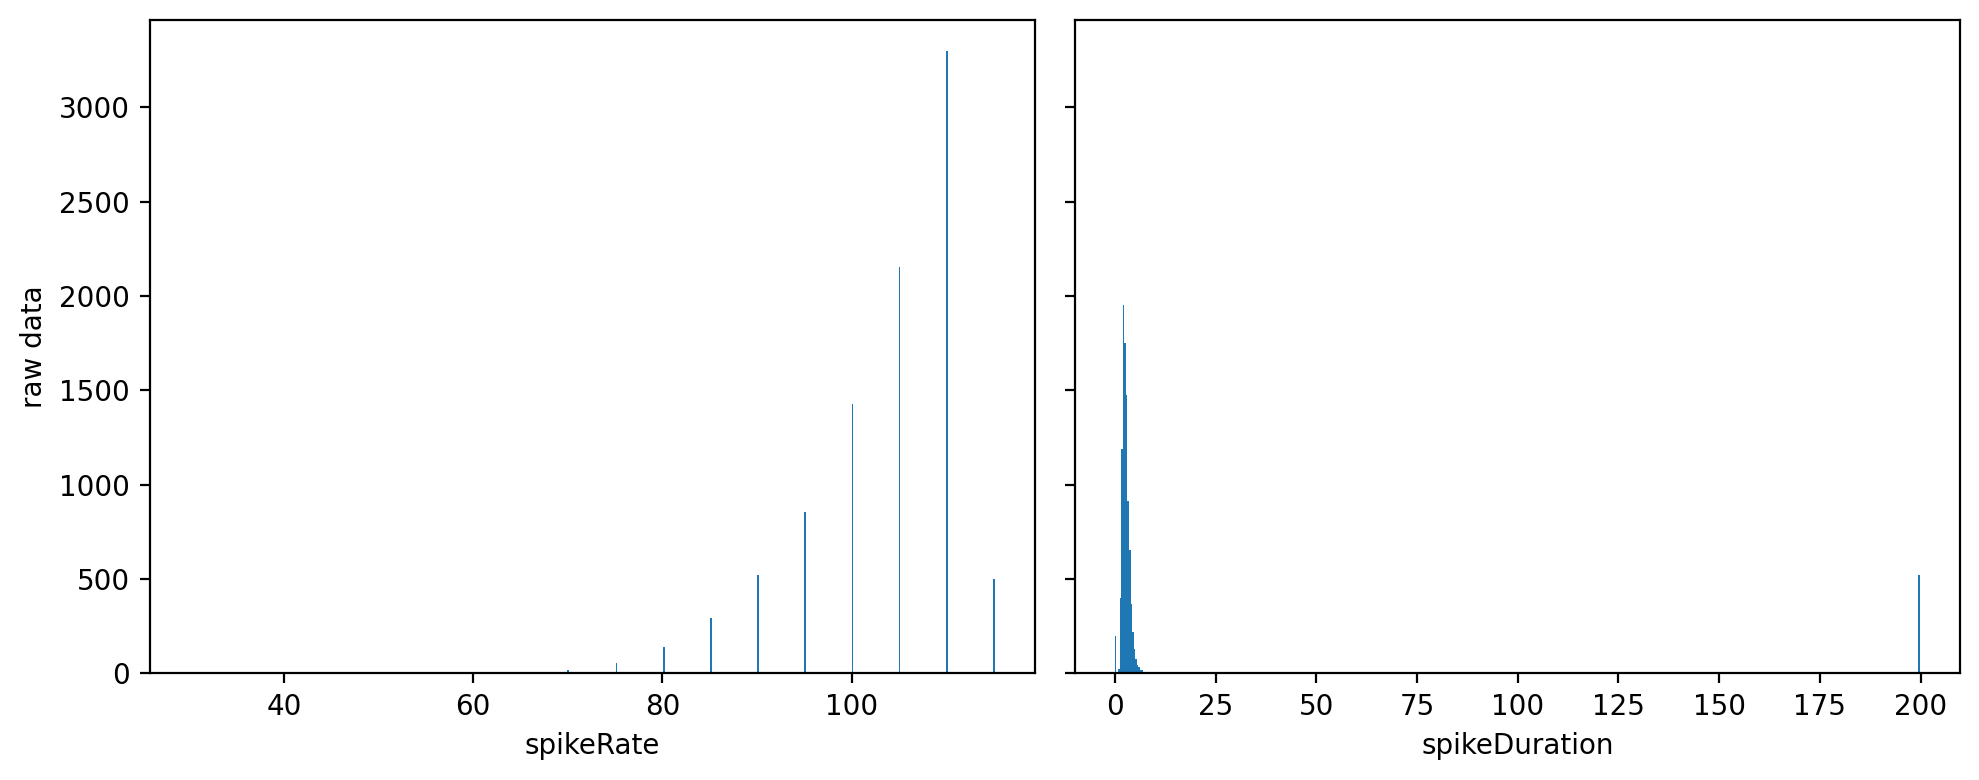

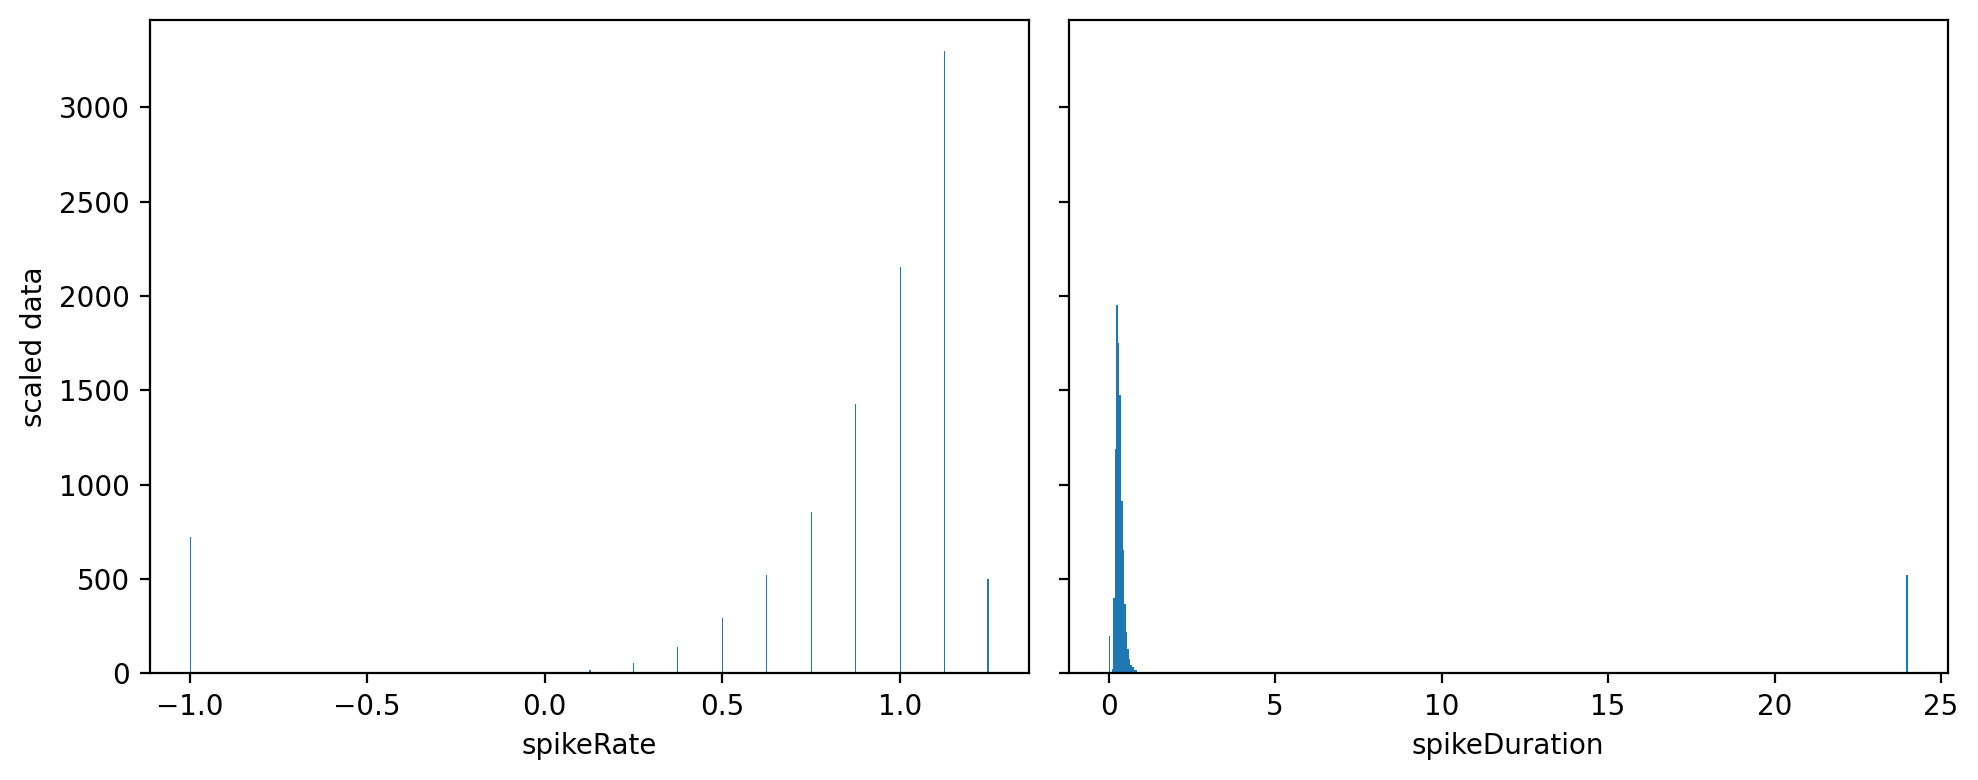

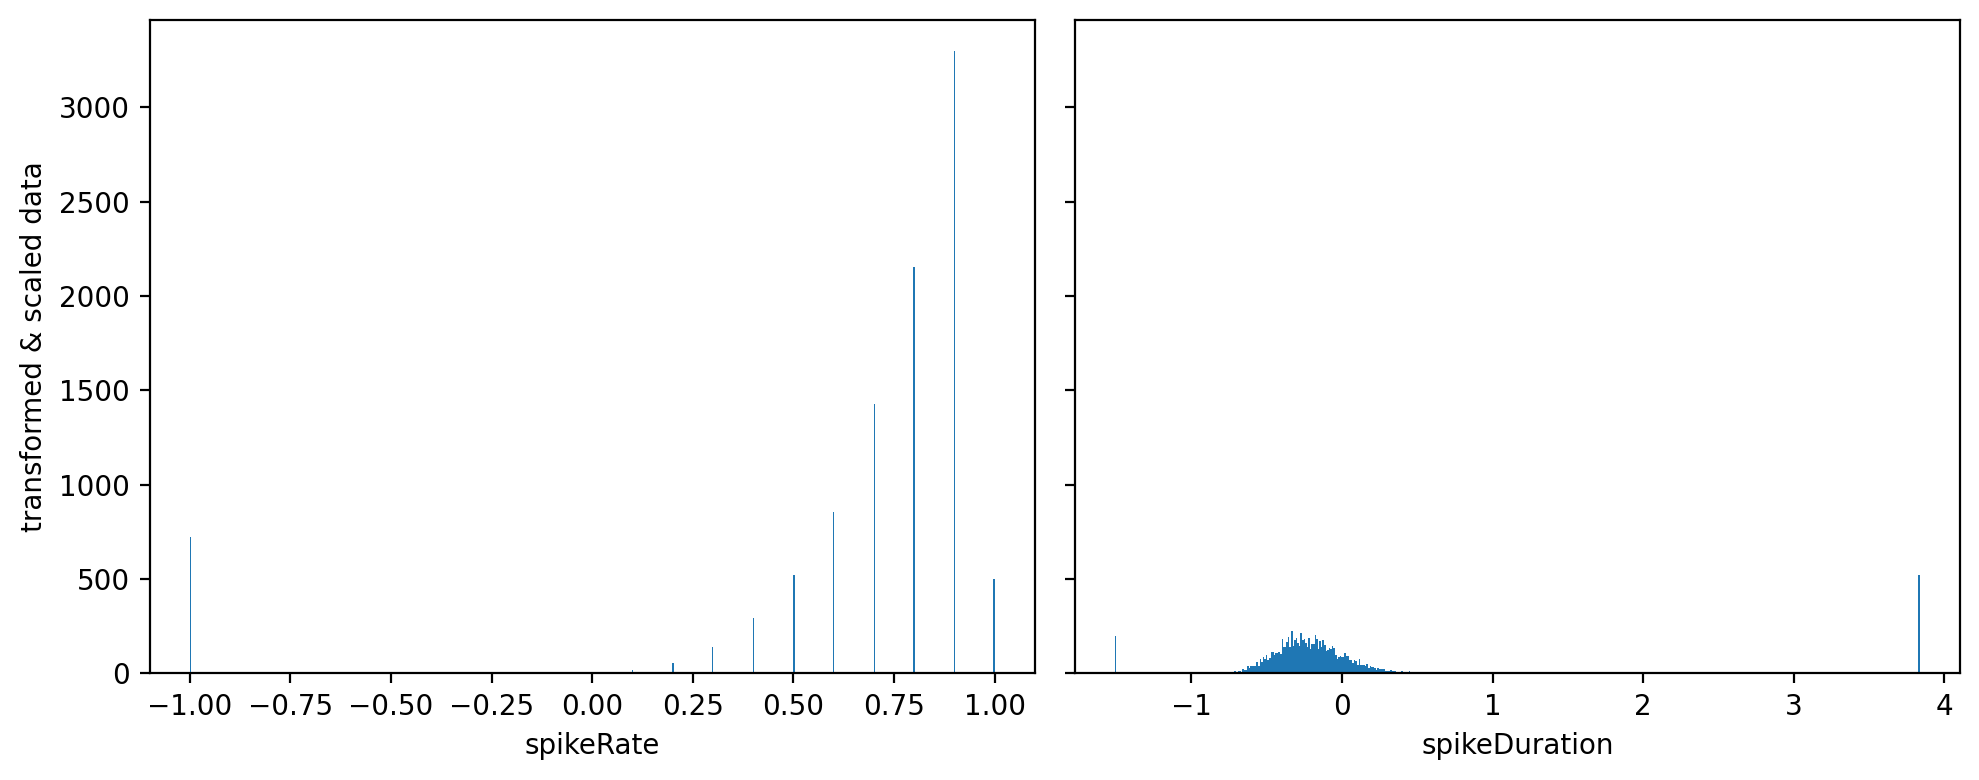

In [7]:
# plot histograms of raw data
fig, ax = plt.subplots(1, 2, figsize=(5*2,4), sharey=True, tight_layout=True)
for i, key in enumerate(['spikeRate', 'spikeDuration']):
    ax[i].hist(samples[key], bins=512)
    ax[i].set_xlabel(key)
ax[0].set_ylabel('raw data')

# plot histograms of scaled data
fig, ax = plt.subplots(1, 2, figsize=(5*2,4), sharey=True, tight_layout=True)
for i, key in enumerate(['spikeRate', 'spikeDuration']):
    ax[i].hist(samples_scaled[key], bins=512)
    ax[i].set_xlabel(key)
ax[0].set_ylabel('scaled data')

# plot histograms of transformed data
fig, ax = plt.subplots(1, 2, figsize=(5*2,4), sharey=True, tight_layout=True)
for i, key in enumerate(['spikeRate', 'spikeDuration']):
    ax[i].hist(samples_transformed[key], bins=512)
    ax[i].set_xlabel(key)
ax[0].set_ylabel('transformed & scaled data')

plt.show()

# Slice

In [8]:
def _filter_samples(features, targets, position, threshold):
    for i, (pos, thresh) in enumerate(zip(position, threshold)):
        features_ = features[...,i].flatten()
        idx_thresh = np.logical_and((pos - thresh) < features_, features_ < (pos + thresh))
        if 0 == i:
            indices = idx_thresh
        else:
            indices = np.logical_and(indices, idx_thresh)
    return features[indices], targets[indices]

def plot_scatter(selected_values, threshold, features, targets, x_lim, y_lim):
    fig, ax = plt.subplots(len(selected_values['spikeRate']), len(selected_values['spikeDuration']), figsize=(12, 12))

    for i, sr in enumerate(selected_values['spikeRate']):
        for j, sd in enumerate(selected_values['spikeDuration']):
            features_thresh, targets_thresh = _filter_samples(
                features, targets,
                [sr, sd], [threshold['spikeRate'], threshold['spikeDuration']]
            )

            # plot points
            ax[i,j].scatter(targets_thresh[:,0], targets_thresh[:,1], s=2**2)
            ax[i,j].set_xlim(x_lim)
            ax[i,j].set_ylim(y_lim)
            if i+1 < len(selected_values['spikeRate']):
                ax[i,j].set_xticklabels([])
            else:
                ax[i,j].set_xlabel('spike duration = {:.3}'.format(sd))
            if 0 < j:
                ax[i,j].set_yticklabels([])
            else:
                ax[i,j].set_ylabel('spike rate = {:.3}'.format(sr))

    fig.tight_layout()

def plot_histogram(selected_values, threshold, features, targets, x_lim, y_lim):
    fig, ax = plt.subplots(len(selected_values['spikeRate']), len(selected_values['spikeDuration']), figsize=(12, 12))

    for i, sr in enumerate(selected_values['spikeRate']):
        for j, sd in enumerate(selected_values['spikeDuration']):
            features_thresh, targets_thresh = _filter_samples(
                features, targets,
                [sr, sd], [threshold['spikeRate'], threshold['spikeDuration']]
            )

            # plot points
            ax[i,j].hist2d(targets_thresh[:,0], targets_thresh[:,1], bins=64, cmap='magma_r', range=[x_lim, y_lim])
            if i+1 < len(selected_values['spikeRate']):
                ax[i,j].set_xticklabels([])
            else:
                ax[i,j].set_xlabel('spike duration = {:.3}'.format(sd))
            if 0 < j:
                ax[i,j].set_yticklabels([])
            else:
                ax[i,j].set_ylabel('spike rate = {:.3}'.format(sr))

    fig.tight_layout()

## Scaled data

In [9]:
def _get_slice_positions_from_histogram(data, range, n_bins, relevant_bins_threshold):
    hist, bin_edges = np.histogram(data.flatten(), range=range, bins=n_bins)
    relevant_bin_indices = hist > relevant_bins_threshold
    relevant_bin_edges   = (bin_edges[:-1])[relevant_bin_indices]
    n_relevant_bins      = np.sum(relevant_bin_indices)
    print(f"Number of relevant bins:  {n_relevant_bins}")
    print(f"Range of relevant values: {relevant_bin_edges[0]} ... {relevant_bin_edges[-1]}")
    with np.printoptions(precision=3, suppress=True):
        print('Relevant values:')
        print(relevant_bin_edges)
    if 10 < n_relevant_bins:
        slice_positions = np.linspace(relevant_bin_edges[0], relevant_bin_edges[-1], 5)
    else:
        slice_positions = relevant_bin_edges
    return slice_positions

In [10]:
# set number of bins
lim = {
    'spikeRate':     [0.0, 2.0], 
    'spikeDuration': [0.0, 2.0],
}
n_bins = {
    'spikeRate':     2000, 
    'spikeDuration':  200,
}

# extract relevant values from scaled data
selected_values = dict()
for key in ['spikeRate', 'spikeDuration']:
    print(f"\n[{key}]\n")
    selected_values[key] = _get_slice_positions_from_histogram(
            samples_scaled[key],
            lim[key],
            n_bins[key],
            400
    )
    with np.printoptions(precision=3, suppress=True):
        print(f"\nSelected values for {key}:")
        print(selected_values[key])
        
# override selected values
selected_values = {
    'spikeRate':     [0.625, 0.75 , 0.875, 1.   , 1.125, 1.25 ], 
    'spikeDuration': [0.25, 0.28, 0.29]
}
print('\nOverride selected values...')
for key in ['spikeRate', 'spikeDuration']:
    with np.printoptions(precision=3, suppress=True):
        print(f"\nSelected values for {key}:")
        print(selected_values[key])


[spikeRate]

Number of relevant bins:  6
Range of relevant values: 0.625 ... 1.25
Relevant values:
[0.625 0.75  0.875 1.    1.125 1.25 ]

Selected values for spikeRate:
[0.625 0.75  0.875 1.    1.125 1.25 ]

[spikeDuration]

Number of relevant bins:  5
Range of relevant values: 0.23999999463558197 ... 0.2800000011920929
Relevant values:
[0.24 0.25 0.26 0.27 0.28]

Selected values for spikeDuration:
[0.24 0.25 0.26 0.27 0.28]

Override selected values...

Selected values for spikeRate:
[0.625, 0.75, 0.875, 1.0, 1.125, 1.25]

Selected values for spikeDuration:
[0.25, 0.28, 0.29]


In [11]:
# set thresholds
threshold = {
    'spikeRate':     0.01,
    'spikeDuration': 0.02,
}

In [21]:
# set up plotting
# x_lim = [np.min(samples['theta'][:,0]), np.max(samples['theta'][:,0])]
# y_lim = [np.min(samples['theta'][:,1]), np.max(samples['theta'][:,1])]
x_lim = [-0.2, 1.0]
y_lim = [-0.4, 1.2]
print('x_lim:', x_lim)
print('y_lim:', y_lim)

features = np.stack((samples_scaled['spikeRate'], samples_scaled['spikeDuration']), -1)
targets  = samples['theta']

x_lim: [-0.2, 1.0]
y_lim: [-0.4, 1.2]


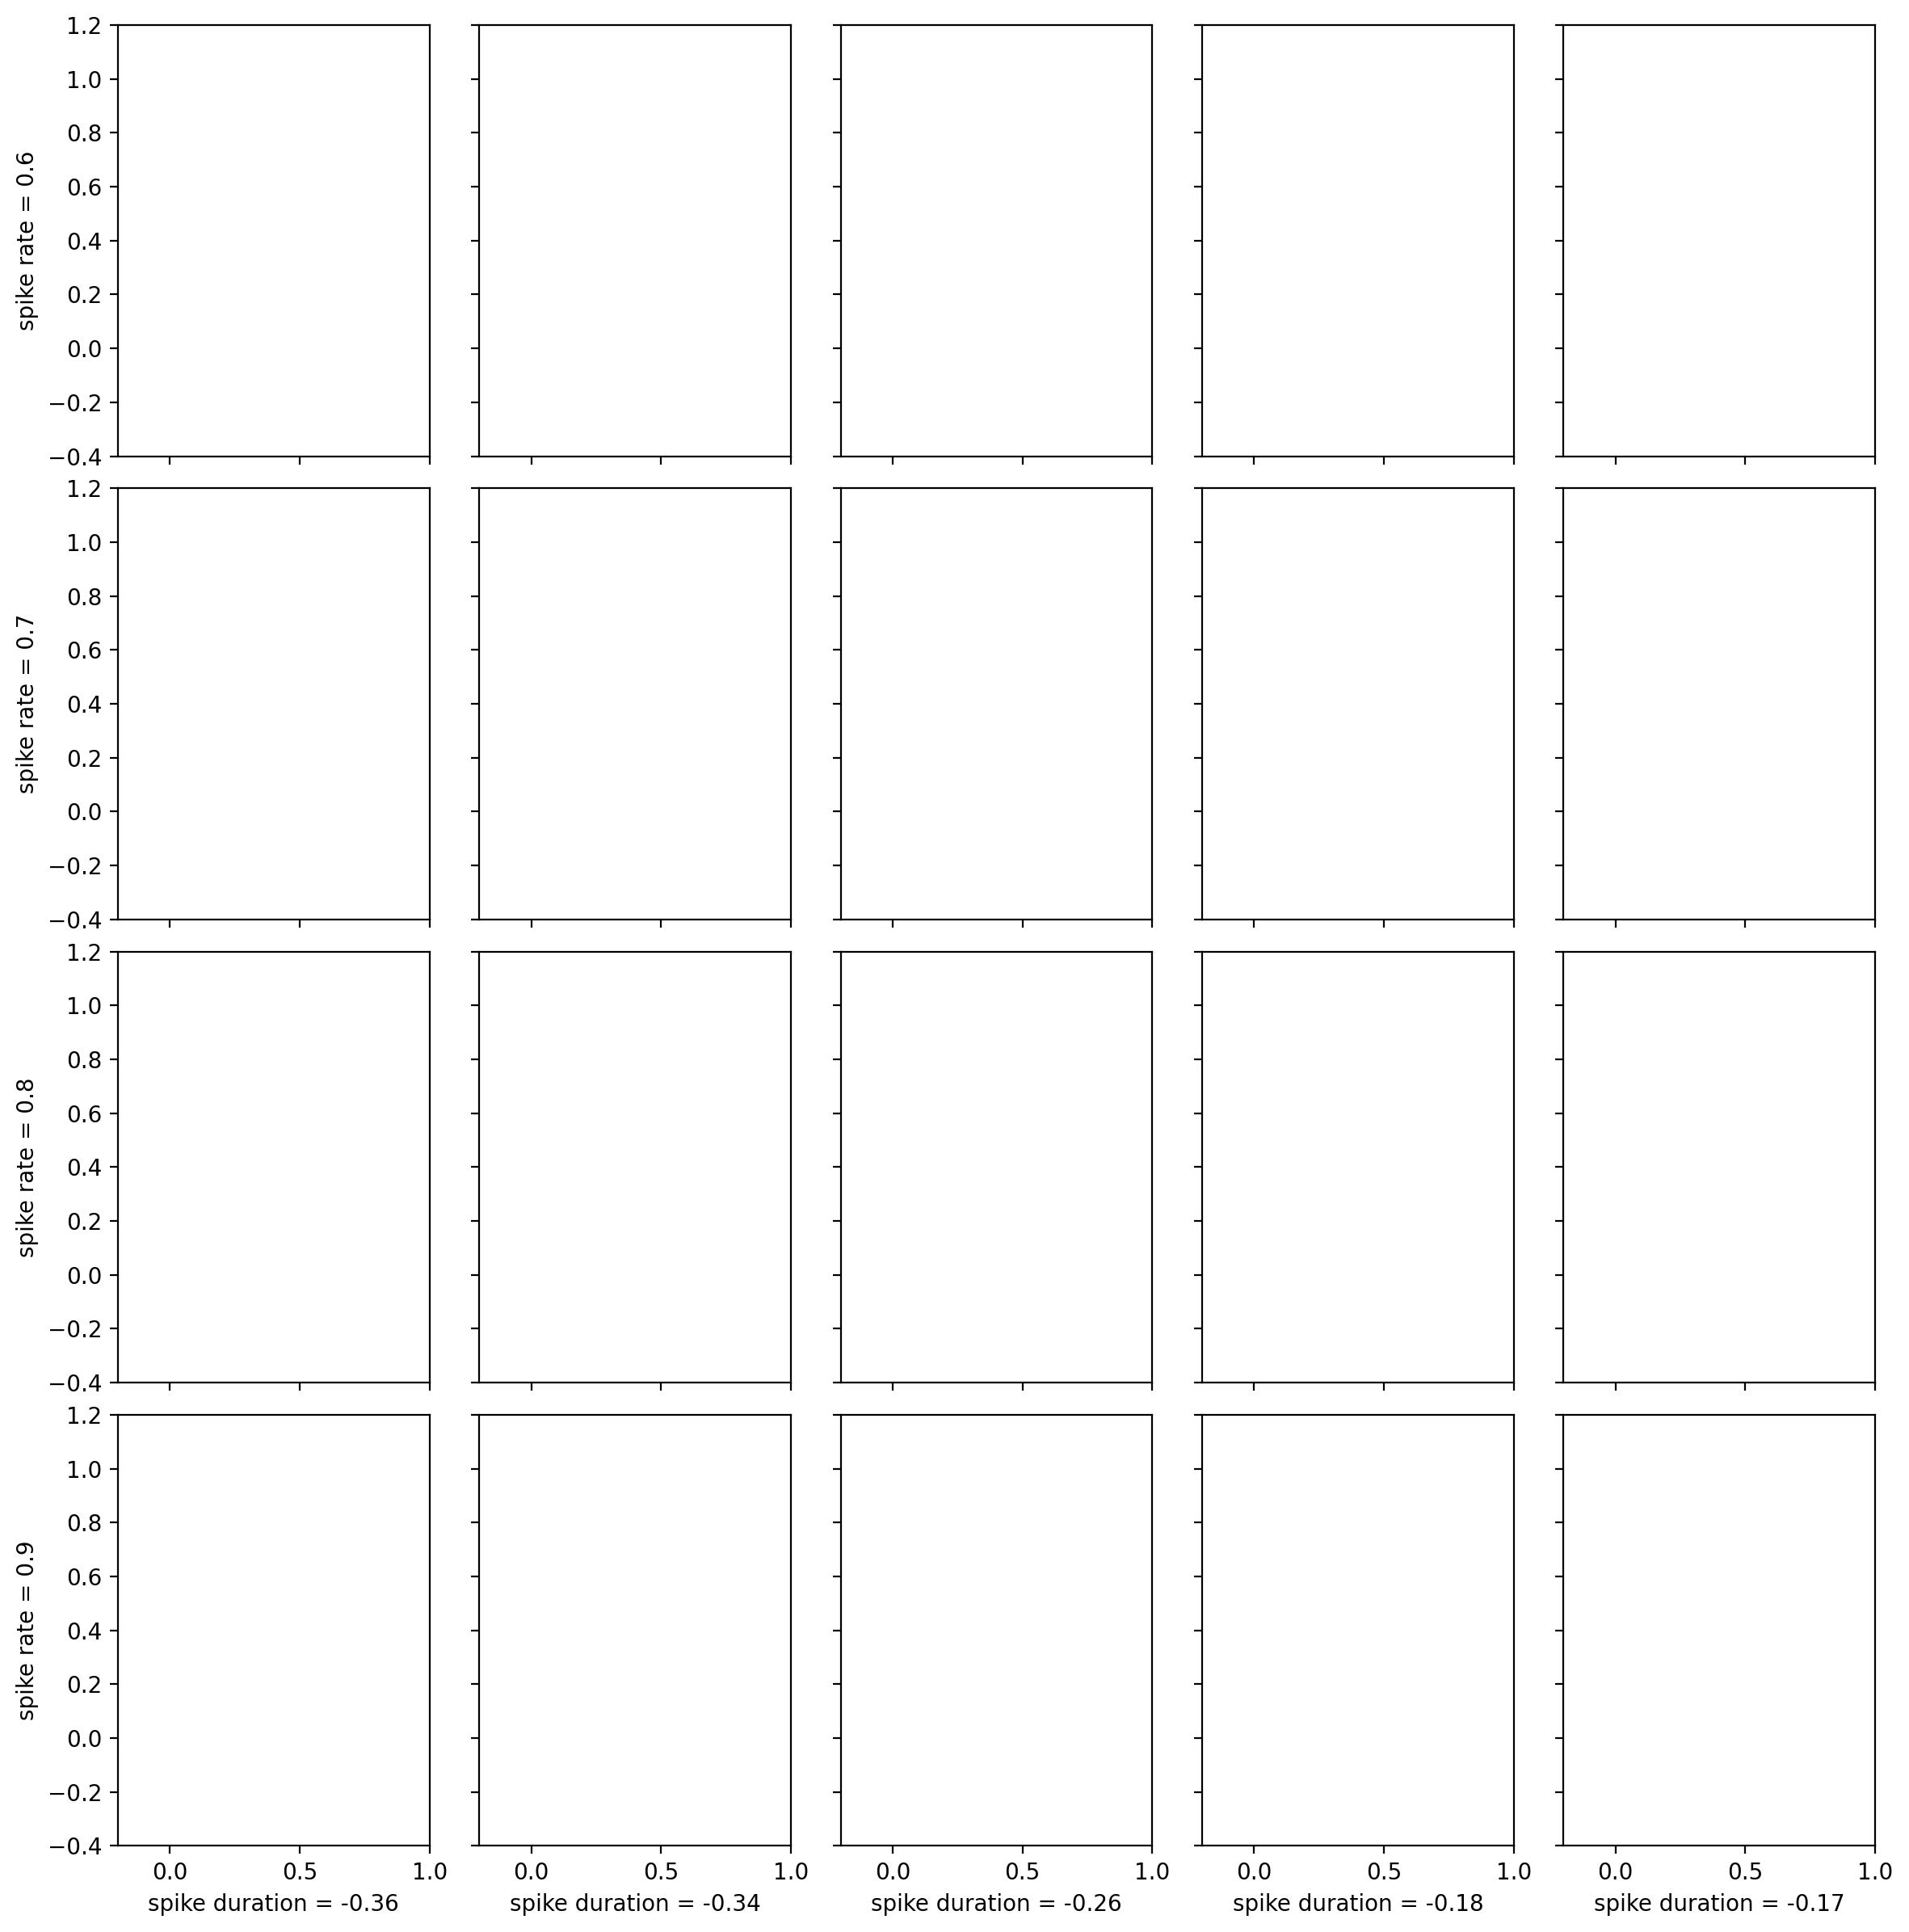

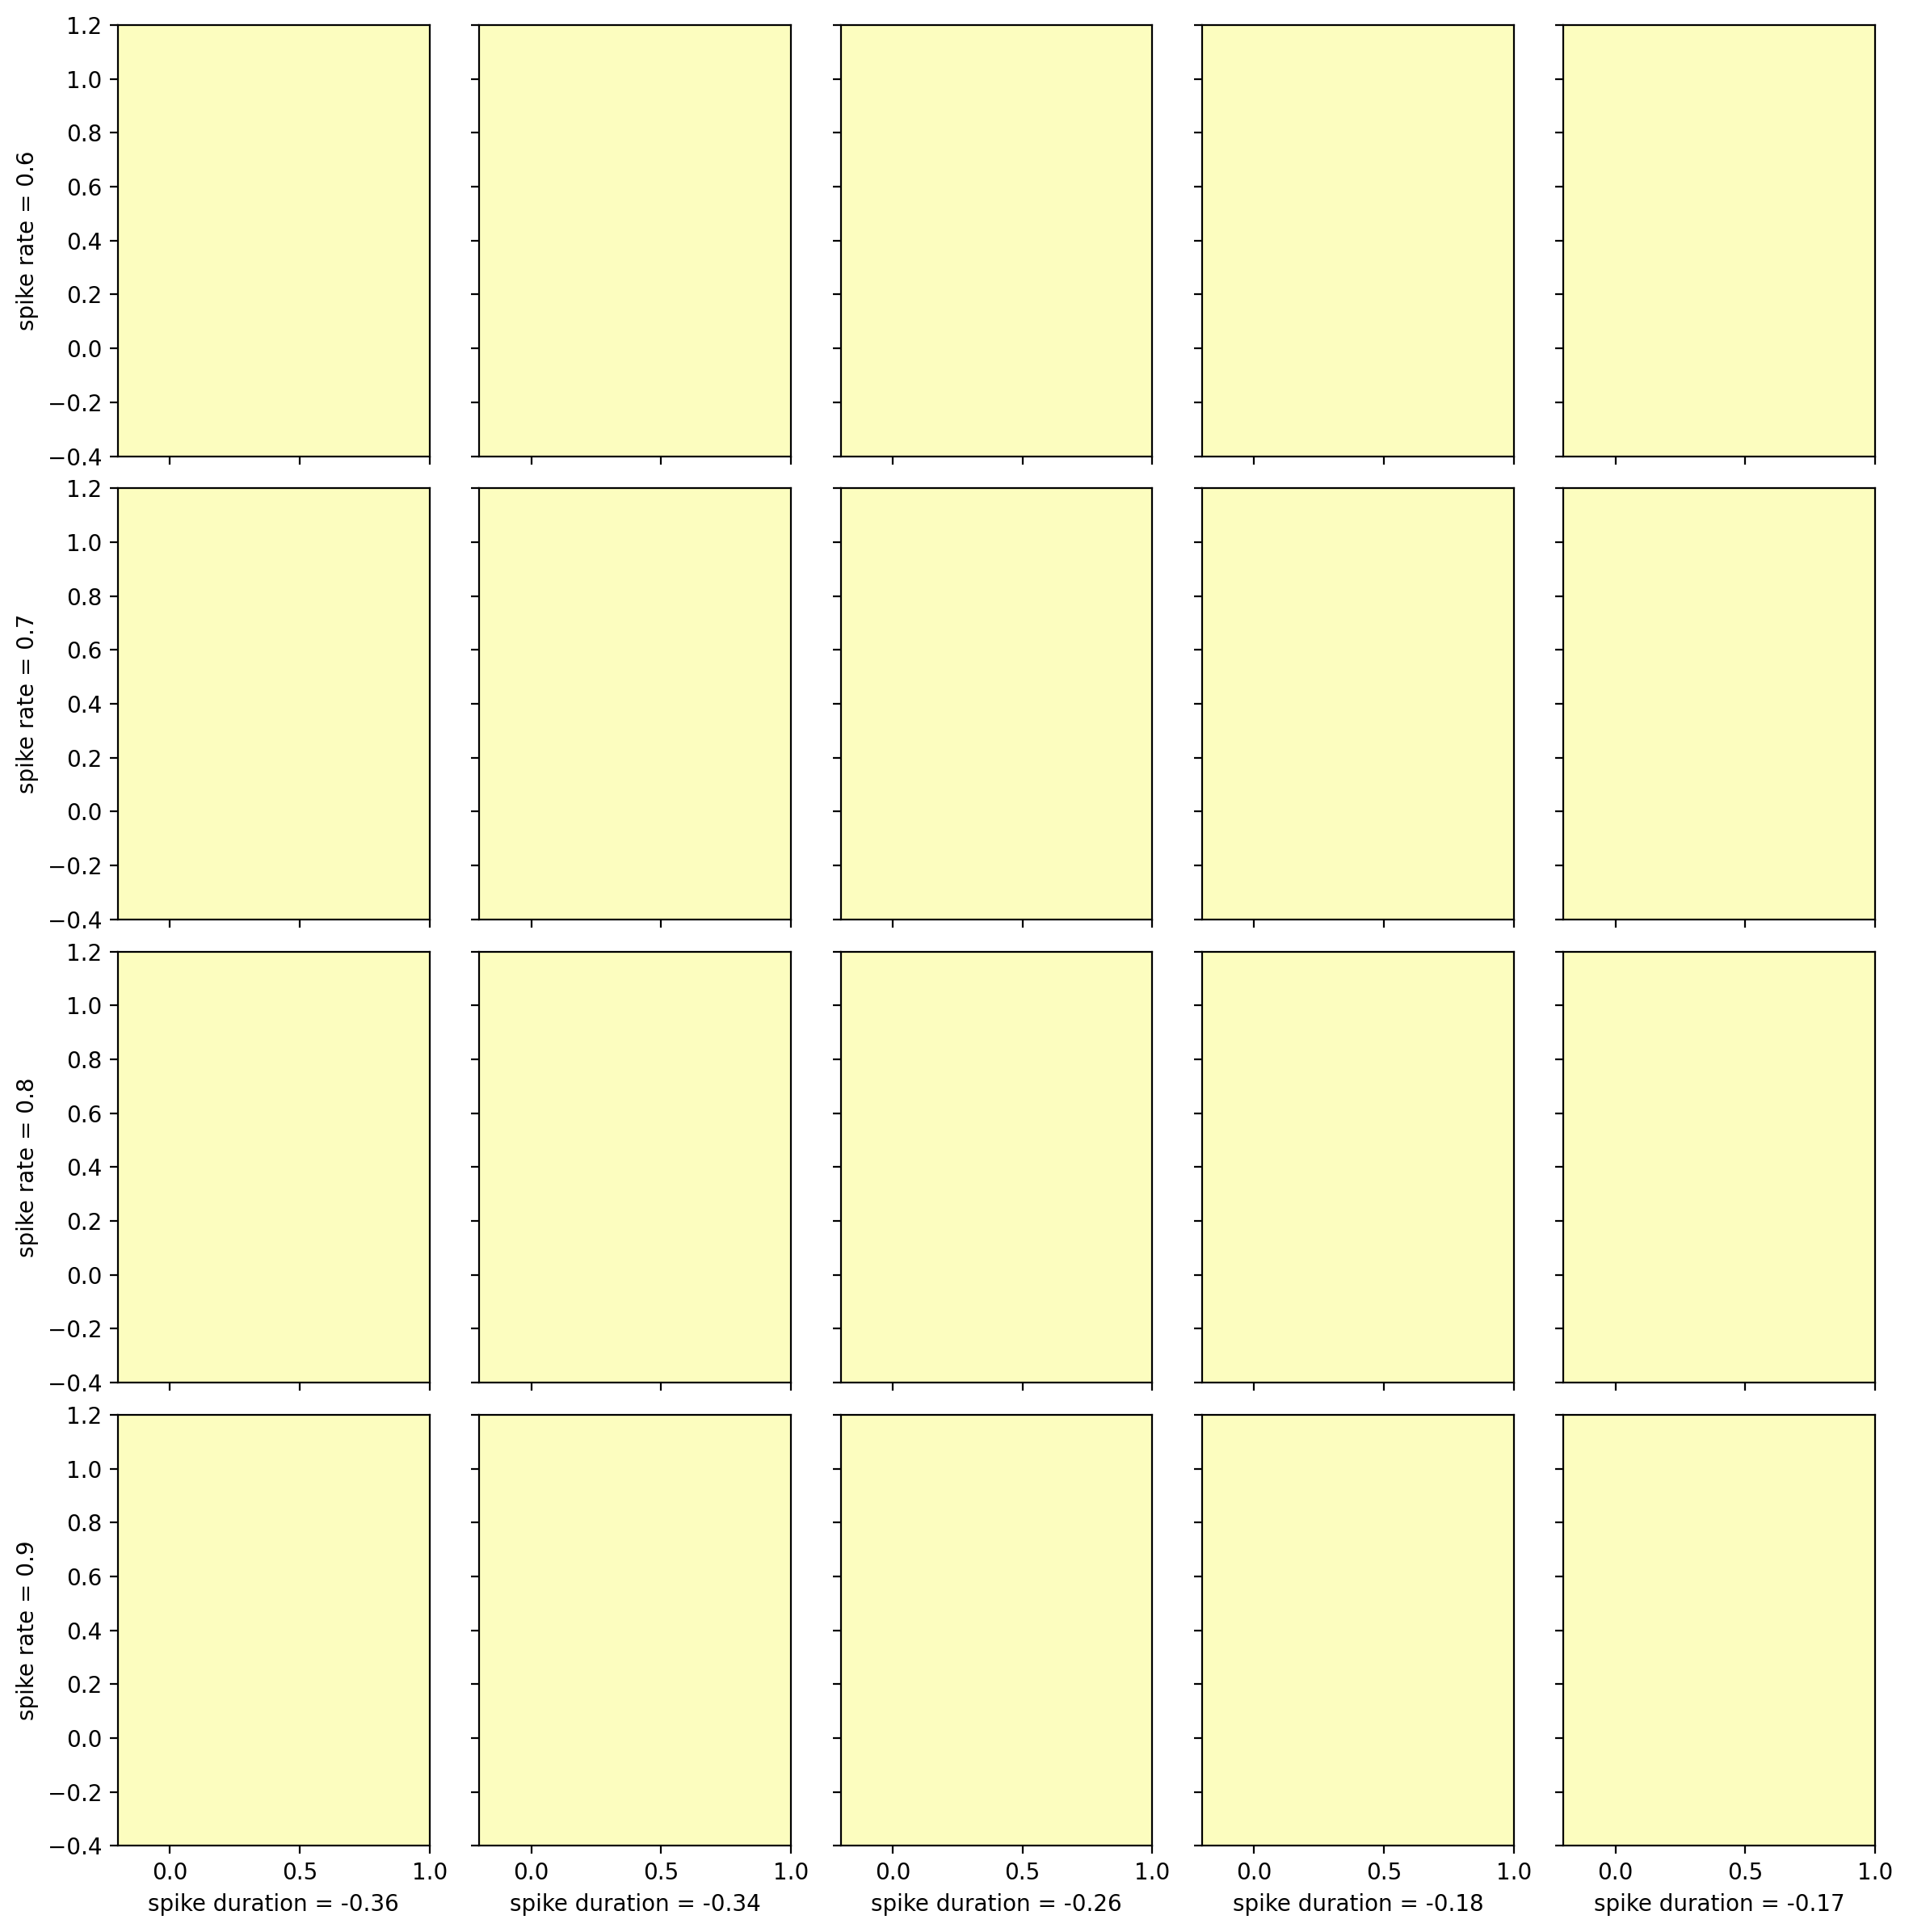

In [22]:
# create plots
plot_scatter  (selected_values, threshold, features, targets, x_lim, y_lim)
plot_histogram(selected_values, threshold, features, targets, x_lim, y_lim)
plt.show()

## Transformed data

In [23]:
# set number of bins
lim = {
    'spikeRate':     [0.0, 2.0], 
    'spikeDuration': [-2.0, 2.0],
}
n_bins = {
    'spikeRate':     2000, 
    'spikeDuration':  100,
}

# extract relevant values from transformed data
selected_values = dict()
for key in ['spikeRate', 'spikeDuration']:
    print(f"\n[{key}]\n")
    selected_values[key] = _get_slice_positions_from_histogram(
            samples_transformed[key],
            lim[key],
            n_bins[key],
            600
    )
    with np.printoptions(precision=3, suppress=True):
        print(f"\nSelected values for {key}:")
        print(selected_values[key])
        
# override selected values
selected_values = {
    'spikeRate':     [0.6, 0.7, 0.8, 0.9], 
    'spikeDuration': [-0.36, -0.34, -0.26, -0.18, -0.17]
}
print('\nOverride selected values...')
for key in ['spikeRate', 'spikeDuration']:
    with np.printoptions(precision=3, suppress=True):
        print(f"\nSelected values for {key}:")
        print(selected_values[key])


[spikeRate]

Number of relevant bins:  4
Range of relevant values: 0.6000000238418579 ... 0.8999999761581421
Relevant values:
[0.6 0.7 0.8 0.9]

Selected values for spikeRate:
[0.6 0.7 0.8 0.9]

[spikeDuration]

Number of relevant bins:  4
Range of relevant values: -0.36000001430511475 ... -0.20000000298023224
Relevant values:
[-0.36 -0.32 -0.28 -0.2 ]

Selected values for spikeDuration:
[-0.36 -0.32 -0.28 -0.2 ]

Override selected values...

Selected values for spikeRate:
[0.6, 0.7, 0.8, 0.9]

Selected values for spikeDuration:
[-0.36, -0.34, -0.26, -0.18, -0.17]


In [24]:
# set thresholds
threshold = {
    'spikeRate':     0.01,
    'spikeDuration': 0.01, #0.10,
}

In [25]:
# set up plotting
# x_lim = [np.min(samples['theta'][:,0]), np.max(samples['theta'][:,0])]
# y_lim = [np.min(samples['theta'][:,1]), np.max(samples['theta'][:,1])]
x_lim = [-0.2, 1.0]
y_lim = [-0.4, 1.2]
print('x_lim:', x_lim)
print('y_lim:', y_lim)

features = np.stack((samples_transformed['spikeRate'], samples_transformed['spikeDuration']), -1)
targets  = samples['theta']

x_lim: [-0.2, 1.0]
y_lim: [-0.4, 1.2]


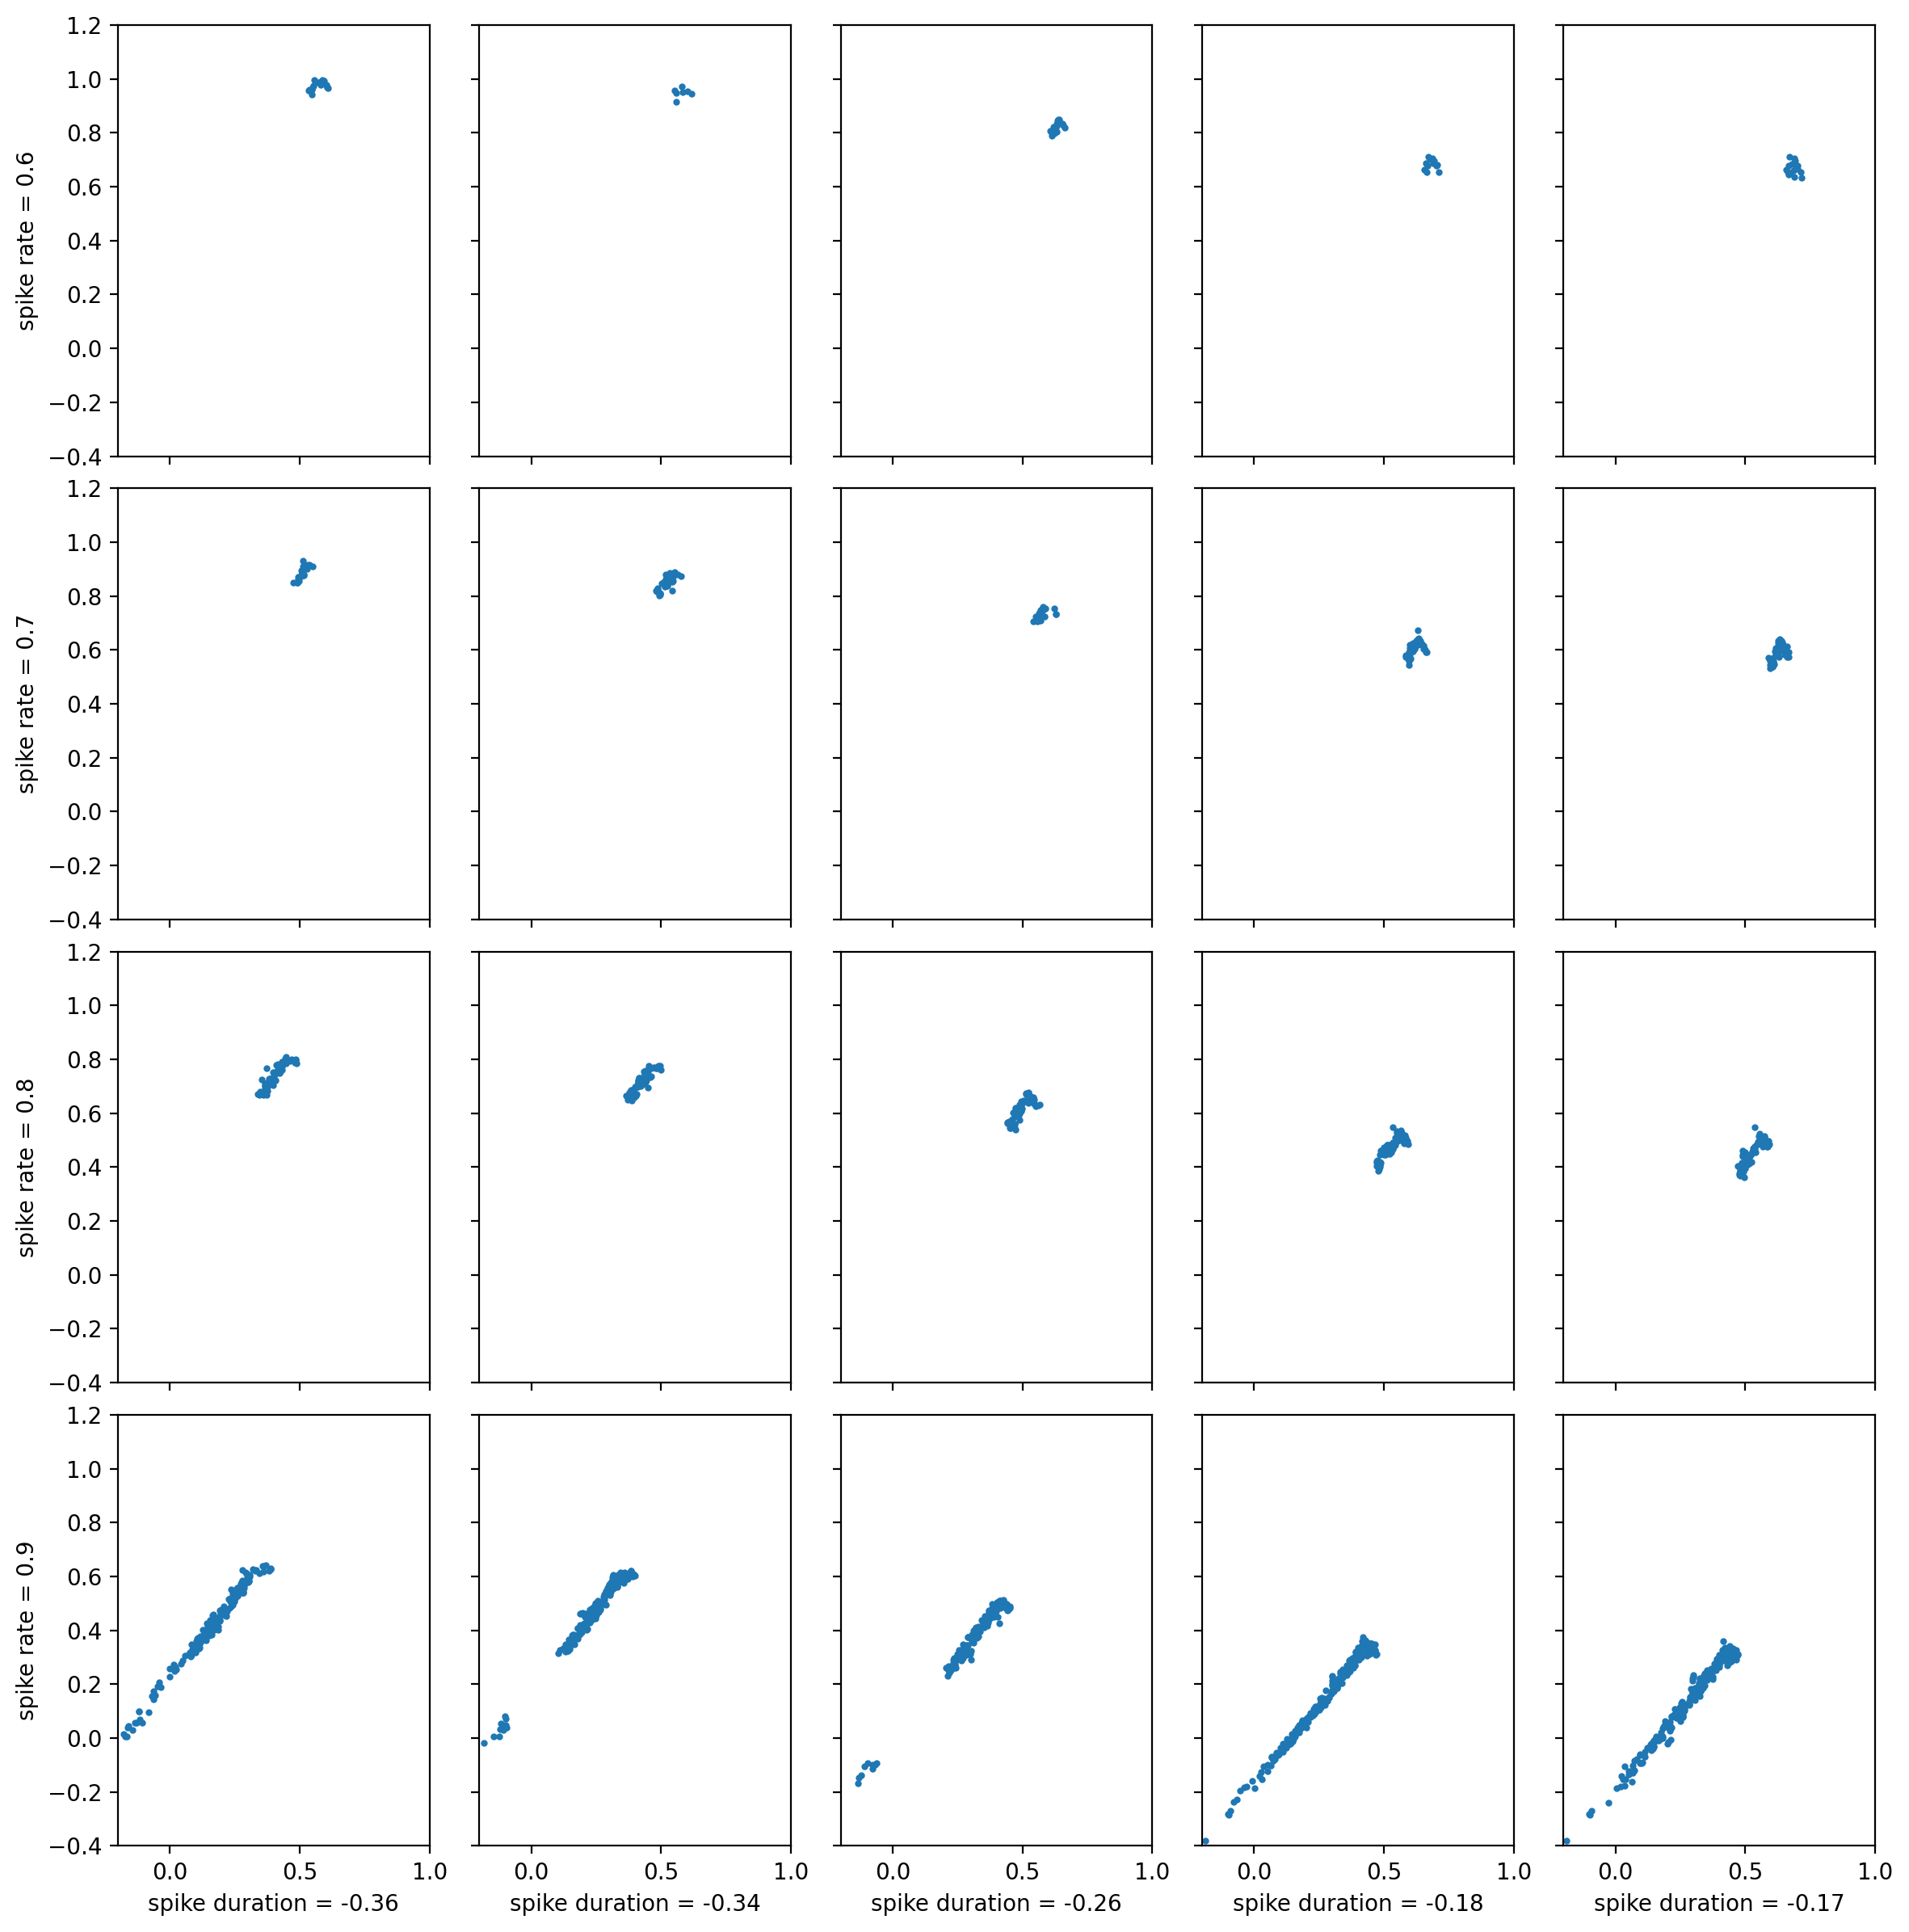

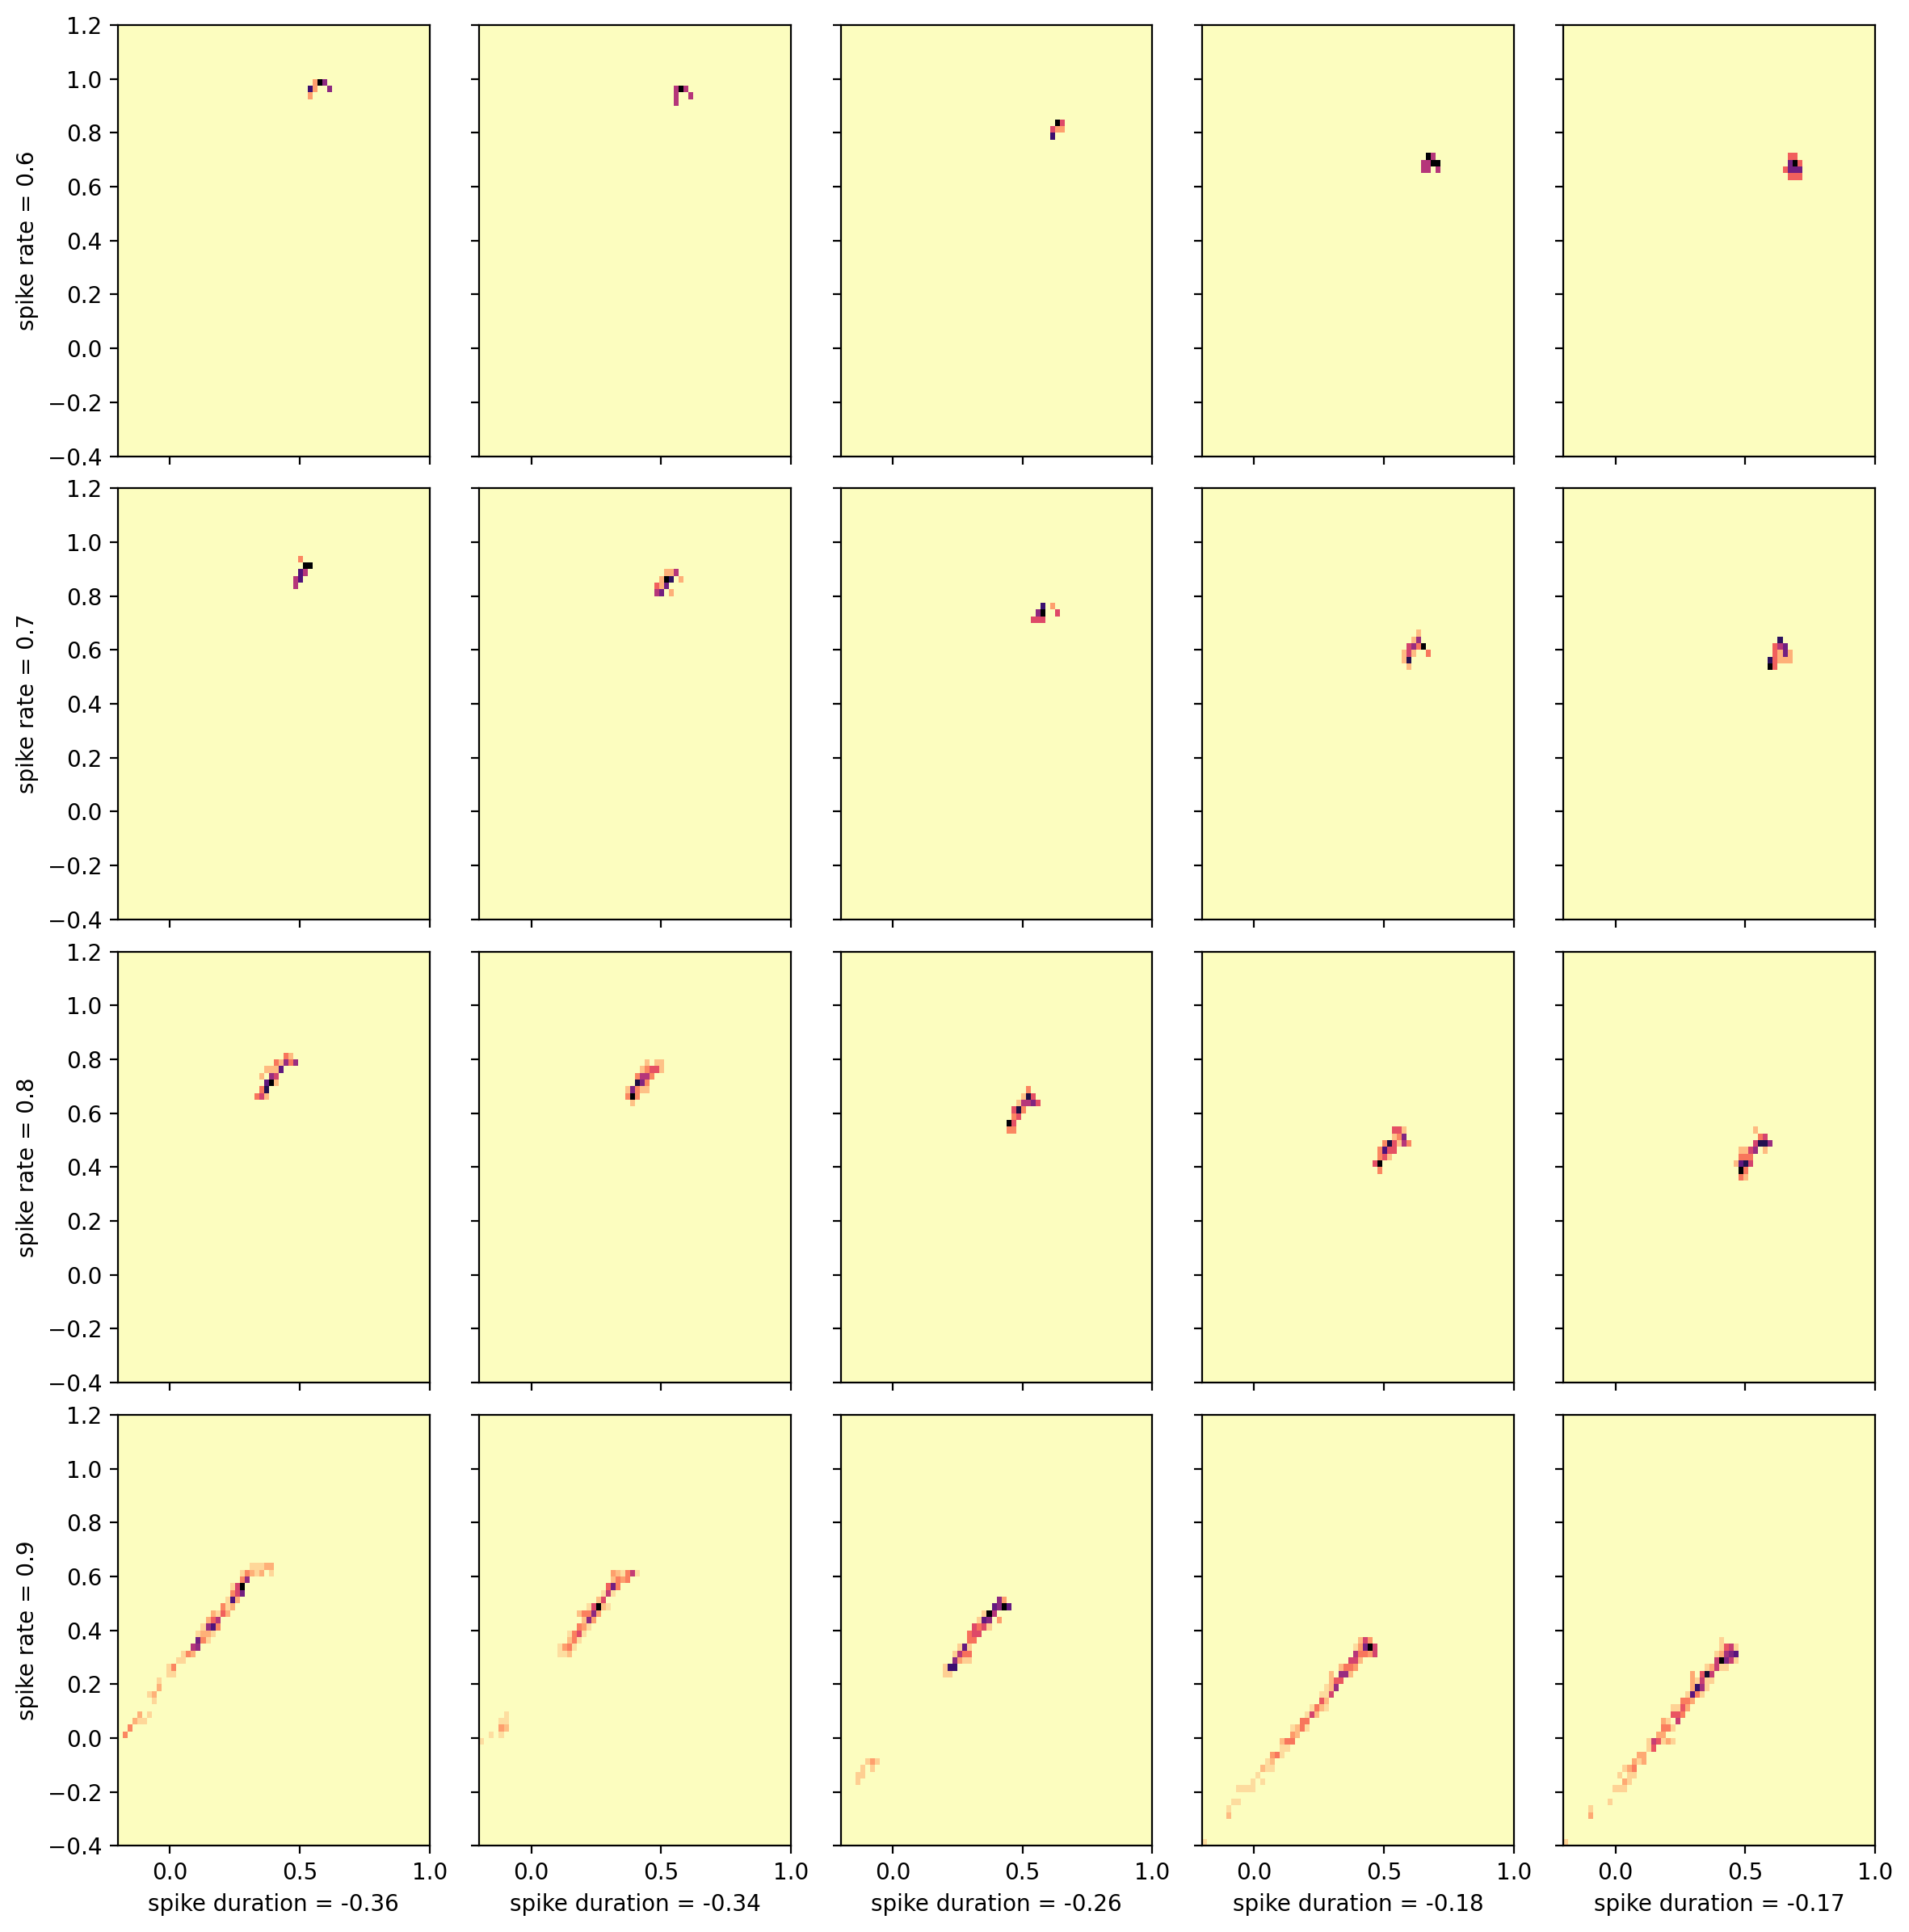

In [26]:
# create plots
plot_scatter  (selected_values, threshold, features, targets, x_lim, y_lim)
plot_histogram(selected_values, threshold, features, targets, x_lim, y_lim)
plt.show()